In [1]:
import numpy as np
import matplotlib.pyplot as plt

/home/coldstream/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [55]:
def read_data(path, skip):
    return np.genfromtxt(path, skip_header=skip)

def autocorrelation(data):
    n_measurements = len(data[:,0])
    corr_t = np.zeros(n_measurements)
    avgmodsq = np.sum(data*data)/n_measurements
    for i in range(n_measurements):
        back_index = n_measurements - i
        if ((i%1000)==0):
            print(i, back_index)
        dot_prods = data[i:, :] * data[:back_index, :] / avgmodsq
        avg_dot_prods = np.mean(np.sum(dot_prods, axis=1))
        corr_t[i] = corr_t[i] + avg_dot_prods 
    return corr_t


path = './sigma5/really_long_run/sim_1/data_sus_frozen_5.0'
nskip = 1800000
nsims = 8
#alt_path = './100_pressure.dat'

corr_t = np.zeros(len(read_data(path, nskip)))

for i in range(nsims):
    path = f'./sigma5/really_long_run/sim_{i+1}/data_sus_frozen_5.0'

    magnetization_t = read_data(path, nskip)
    #magnetization_t = alt_read_data(alt_path, 4950000)
    corr_t += autocorrelation(magnetization_t)

corr_t = corr_t/nsims


0 200001
1000 199001
2000 198001
3000 197001
4000 196001
5000 195001
6000 194001
7000 193001
8000 192001
9000 191001
10000 190001
11000 189001
12000 188001
13000 187001
14000 186001
15000 185001
16000 184001
17000 183001
18000 182001
19000 181001
20000 180001
21000 179001
22000 178001
23000 177001
24000 176001
25000 175001
26000 174001
27000 173001
28000 172001
29000 171001
30000 170001
31000 169001
32000 168001
33000 167001
34000 166001
35000 165001
36000 164001
37000 163001
38000 162001
39000 161001
40000 160001
41000 159001
42000 158001
43000 157001
44000 156001
45000 155001
46000 154001
47000 153001
48000 152001
49000 151001
50000 150001
51000 149001
52000 148001
53000 147001
54000 146001
55000 145001
56000 144001
57000 143001
58000 142001
59000 141001
60000 140001
61000 139001
62000 138001
63000 137001
64000 136001
65000 135001
66000 134001
67000 133001
68000 132001
69000 131001
70000 130001
71000 129001
72000 128001
73000 127001
74000 126001
75000 125001
76000 124001
77000 123001

In [56]:
print(corr_t)



np.savetxt('correlation.dat', corr_t)



[ 1.          0.99538098  0.99273639 ... -0.16222094 -0.16903234
 -0.18546827]


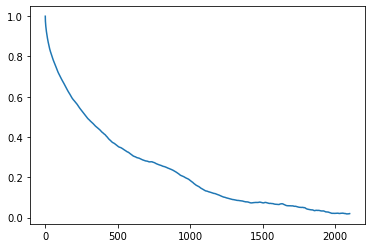

In [ ]:
dt = 20*0.001
t = np.arange(len(corr_t))*dt

corr_t = corr_t[:2100*500]

#plt.xlim([0,1])
plt.plot(t, corr_t)

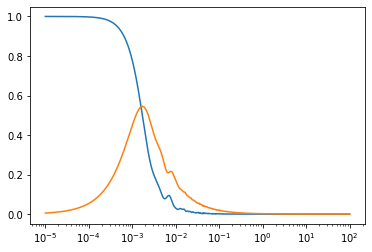

In [77]:
### Do the fourier transform
### frequencies to sample, distributed evenly in logspace
omegas = 10**(np.linspace(-5,2,num=1000))
re_chi_omega = np.zeros(len(omegas))
im_chi_omega = np.zeros(len(omegas))

for i, omega in enumerate(omegas):
    for t, c in enumerate(corr_t):
        re_chi_omega[i] += c * np.cos(omega*t*0.001*20)
        im_chi_omega[i] += c * np.sin(omega*t*0.001*20)

### Normalise the output
norm_const = re_chi_omega[0]
re_chi_omega = re_chi_omega/norm_const
im_chi_omega = im_chi_omega/norm_const

plt.xscale('log')
plt.plot(omegas, re_chi_omega)
plt.plot(omegas, im_chi_omega)





In [128]:
#corr_t = np.zeros(len(read_data(path, nskip)))
nskip = 200000
nsims = 8
nanalyse = 0
corr_t = np.zeros((nsims, 500000))
norm = np.zeros((nsims))

#corr_t = autocorrelation(read_data('./sigma10/long_run/sim_1/chain_magnetisation.dat', 20000))

for i in range(nsims):
    
    path = f'./sigma10/long_run/sim_{i+1}/chain_magnetisation.dat'
    
    magnetization_t = read_data(path, nskip)
    if (len(magnetization_t) > 0):
        temp_corr_t = autocorrelation(magnetization_t)
        corr_t[i, len(temp_corr_t):] += temp_corr_t

for i in range(nsims):
    dt = 20*0.001
    t = np.arange(len(corr_t))*dt
    plt.plot(t, corr_t)




### for i in range(nsims):
###     path = f'./sigma10/long_run/sim_{i+1}/chain_magnetisation.dat'
###     print(path)
### 
###     magnetization_t = read_data(path, nskip)
###     print(magnetization_t)
###     print(len(magnetization_t))
###     print(len(temp_corr_t))
###     norm[i] = len(temp_corr_t)
###     print("norm i = ", norm[i])
###     if (len(magnetization_t) > 0):
###         temp_corr_t = autocorrelation(magnetization_t)
###         corr_t[:len(temp_corr_t)] += temp_corr_t
### 
### print("Max =", max(norm))
### norm_consts = np.zeros((int(max(norm))))
### for i in norm:
###     norm_consts[:int(i)] += 1
### corr_t[:len(norm_consts)] /= norm_consts
### 
### dt = 20*0.001
### t = np.arange(len(corr_t))*dt
### 
### plt.plot(t, corr_t)


0 245397
1000 244397
2000 243397
3000 242397
4000 241397
5000 240397
6000 239397
7000 238397
8000 237397
9000 236397
10000 235397
11000 234397
12000 233397
13000 232397
14000 231397
15000 230397
16000 229397
17000 228397
18000 227397
19000 226397
20000 225397
21000 224397
22000 223397
23000 222397
24000 221397
25000 220397
26000 219397
27000 218397
28000 217397
29000 216397
30000 215397
31000 214397
32000 213397
33000 212397
34000 211397
35000 210397
36000 209397
37000 208397
38000 207397
39000 206397
40000 205397
41000 204397
42000 203397
43000 202397
44000 201397
45000 200397
46000 199397
47000 198397
48000 197397
49000 196397
50000 195397
51000 194397
52000 193397
53000 192397
54000 191397
55000 190397
56000 189397
57000 188397
58000 187397
59000 186397
60000 185397
61000 184397
62000 183397
63000 182397
64000 181397
65000 180397
66000 179397
67000 178397
68000 177397
69000 176397
70000 175397
71000 174397
72000 173397
73000 172397
74000 171397
75000 170397
76000 169397
77000 168397

ValueError: operands could not be broadcast together with shapes (254603,) (245397,) (254603,) 